# Limpieza

In [3]:
import pandas as pd
import numpy as np

In [4]:
tabla = pd.read_csv('dirty_cafe_sales.csv')

In [5]:
tabla.shape

(10000, 8)

In [6]:
tabla.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [7]:
#Tipos de productos
tabla['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'UNKNOWN',
       'Sandwich', nan, 'ERROR', 'Juice', 'Tea'], dtype=object)

In [8]:
#Precio de los productos
tabla['Price Per Unit'].unique()

array(['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN'],
      dtype=object)

In [9]:
#Métodos de pago
tabla['Payment Method'].value_counts()

Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

In [10]:
#Localización
tabla['Location'].value_counts()

Location
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64

In [11]:
#Ver tipos de datos de cada columna
tabla.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

In [12]:
#Cambiar tipos de datos
tabla.Quantity = pd.to_numeric(tabla.Quantity, errors = 'coerce')
tabla['Price Per Unit'] = pd.to_numeric(tabla['Price Per Unit'], errors = 'coerce')
tabla['Total Spent'] = pd.to_numeric(tabla['Total Spent'], errors = 'coerce')
tabla['Transaction Date'] = pd.to_datetime(tabla['Transaction Date'], errors = 'coerce')
tabla

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [13]:
#Cambiar datos a NaN
tabla['Item'] = tabla['Item'].replace(['ERROR','UNKNOWN'],np.nan)
tabla['Payment Method'] = tabla['Payment Method'].replace(['ERROR','UNKNOWN'],np.nan)
tabla['Location'] = tabla['Location'].replace(['ERROR','UNKNOWN'],np.nan)
tabla

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [14]:
tabla.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [15]:
#fillna de Quantity, total spent y price per unit
tabla['Quantity'] = tabla['Quantity'].fillna(tabla['Total Spent'] / tabla['Price Per Unit'])
tabla['Total Spent'] = tabla['Total Spent'].fillna(tabla['Quantity'] * tabla['Price Per Unit'])
tabla['Price Per Unit'] = tabla['Price Per Unit'].fillna(tabla['Total Spent'] / tabla['Quantity'])

In [16]:
#Crear una tabla con el precio de cada producto
precioporproducto = tabla[['Item','Price Per Unit']].drop_duplicates().dropna().sort_values('Price Per Unit')
precioporproducto

,Item,Price Per Unit
2,Cookie,1.0
42,Tea,1.5
0,Coffee,2.0
1,Cake,3.0
17,Juice,3.0
5,Smoothie,4.0
7,Sandwich,4.0
3,Salad,5.0


In [17]:
#inner join con la tabla original para sustituir todos los NA
tabla = tabla.merge(precioporproducto, 'inner')
tabla

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
8994,TXN_4766549,Smoothie,2.0,4.0,8.0,Cash,NaN,2023-10-20
8995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
8996,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
8997,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


In [18]:
#Eliminar los NA de la columnas Quantity y Total Spent porque no me sirven para calcular la facturacion
tabla = tabla.dropna(subset=['Quantity', 'Total Spent'])

In [19]:
#Eliminar los NA de la columna Transaction Date, porque no me sirven tampoco
tabla = tabla.dropna(subset=['Transaction Date'])

In [20]:
tabla.shape 

(8564, 8)

In [21]:
#Rellenar todos los nulos con el valor de antes
tabla = tabla.ffill()
tabla.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [22]:
tabla

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Credit Card,In-store,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
8994,TXN_4766549,Smoothie,2.0,4.0,8.0,Cash,In-store,2023-10-20
8995,TXN_7672686,Coffee,2.0,2.0,4.0,Cash,In-store,2023-08-30
8996,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,In-store,2023-03-02
8997,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,In-store,2023-12-02


# Análisis

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Ventas de productos
cantidad_productos = tabla.groupby('Item').agg(Cantidad = ('Quantity','sum')).reset_index().sort_values('Cantidad',ascending = False)
cantidad_productos

,Item,Cantidad
1,Coffee,3400.0
3,Juice,3339.0
4,Salad,3309.0
0,Cake,3269.0
5,Sandwich,3249.0
6,Smoothie,3184.0
7,Tea,3093.0
2,Cookie,3065.0


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Coffee'),
  Text(1, 0, 'Juice'),
  Text(2, 0, 'Salad'),
  Text(3, 0, 'Cake'),
  Text(4, 0, 'Sandwich'),
  Text(5, 0, 'Smoothie'),
  Text(6, 0, 'Tea'),
  Text(7, 0, 'Cookie')])

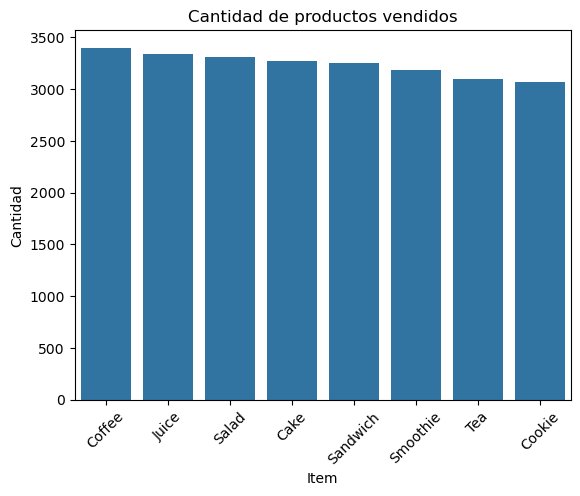

In [26]:
plt.title('Cantidad de productos vendidos')
sns.barplot(
    data = cantidad_productos,
    x = 'Item',
    y = 'Cantidad'
)
plt.xticks(rotation=45)

In [27]:
#Ingresos de productos
facturacion = tabla.groupby('Item').agg(Facturacion = ('Total Spent','sum')).reset_index().sort_values('Facturacion',ascending = False)
facturacion

,Item,Facturacion
4,Salad,16545.0
5,Sandwich,12996.0
6,Smoothie,12736.0
3,Juice,10017.0
0,Cake,9807.0
1,Coffee,6800.0
7,Tea,4639.5
2,Cookie,3065.0


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Salad'),
  Text(1, 0, 'Sandwich'),
  Text(2, 0, 'Smoothie'),
  Text(3, 0, 'Juice'),
  Text(4, 0, 'Cake'),
  Text(5, 0, 'Coffee'),
  Text(6, 0, 'Tea'),
  Text(7, 0, 'Cookie')])

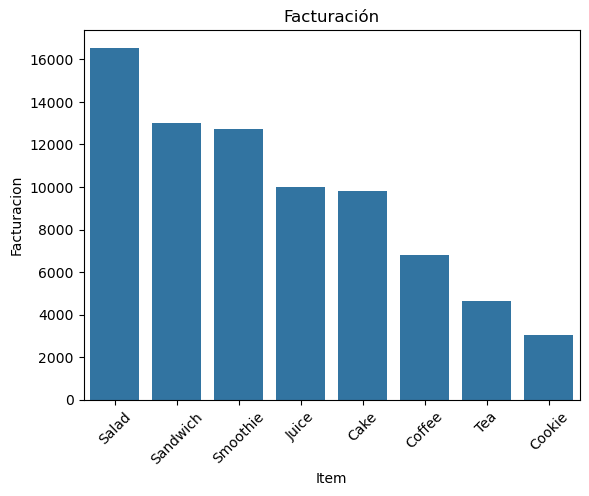

In [28]:
plt.title('Facturación')
sns.barplot(
    data = facturacion,
    x = 'Item',
    y = 'Facturacion'
)
plt.xticks(rotation=45)

In [29]:
#Fecha
ventas_facturacion_dia = tabla.groupby('Transaction Date').agg(
    Total_Ventas = ('Quantity','sum'),
    Facturacion = ('Total Spent','sum')
).reset_index()
ventas_facturacion_dia

,Transaction Date,Total_Ventas,Facturacion
0,2023-01-01,59.0,164.0
1,2023-01-02,58.0,166.5
2,2023-01-03,55.0,179.0
3,2023-01-04,71.0,236.5
4,2023-01-05,102.0,333.0
...,...,...,...
360,2023-12-27,69.0,197.0
361,2023-12-28,62.0,167.0
362,2023-12-29,51.0,148.5
363,2023-12-30,55.0,149.0


<Axes: xlabel='Transaction Date', ylabel='Total_Ventas'>

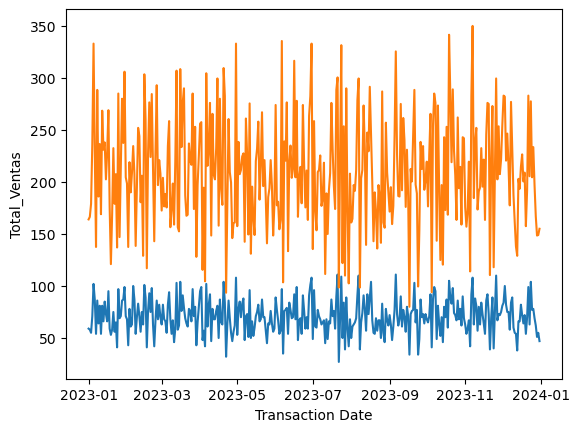

In [30]:
sns.lineplot(
    data = ventas_facturacion_dia,
    x = 'Transaction Date',
    y = 'Total_Ventas'
)
sns.lineplot(
    data = ventas_facturacion_dia,
    x = 'Transaction Date',
    y = 'Facturacion'
)

In [31]:
#Facturacion y ventas por mes
tabla2 = tabla.copy()
tabla2['numero_mes'] = tabla2['Transaction Date'].dt.month
tabla2['mes'] = tabla2['Transaction Date'].dt.month_name()

In [32]:
ventas_facturacion_mes = tabla2.groupby(['numero_mes','mes']).agg(
    Total_Ventas = ('Quantity','sum'),
    Facturacion = ('Total Spent','sum')
).reset_index().sort_values('numero_mes')
ventas_facturacion_mes

,numero_mes,mes,Total_Ventas,Facturacion
0,1,January,2224.0,6655.0
1,2,February,2023.0,5935.5
2,3,March,2227.0,6501.0
3,4,April,2127.0,6453.5
4,5,May,2097.0,6204.0
5,6,June,2214.0,6613.0
6,7,July,2098.0,6174.5
7,8,August,2147.0,6305.0
8,9,September,2095.0,6179.0
9,10,October,2318.0,6736.0


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

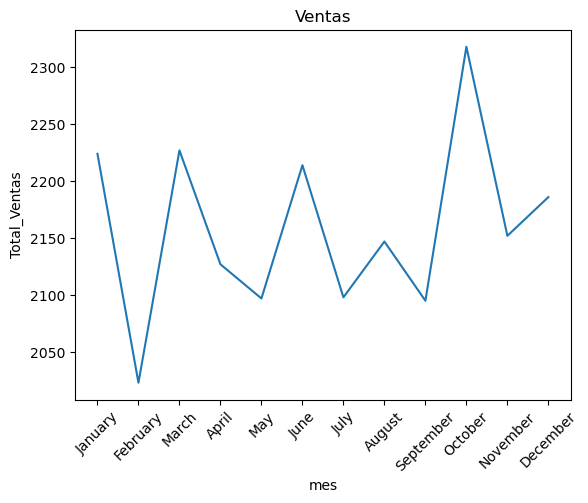

In [33]:
plt.title('Ventas')
sns.lineplot(
    data = ventas_facturacion_mes,
    x = 'mes',
    y = 'Total_Ventas'
)
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

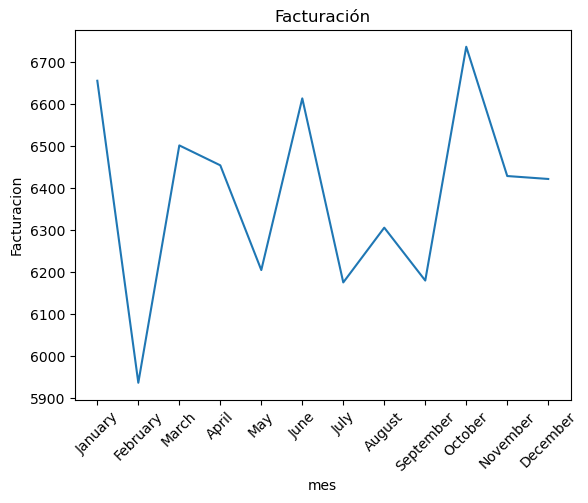

In [34]:
plt.title('Facturación')
sns.lineplot(
    data = ventas_facturacion_mes,
    x = 'mes',
    y = 'Facturacion'
)
plt.xticks(rotation=45)

In [35]:
#Facturación y ventas por día de la semana
tabla2['dia'] = tabla2['Transaction Date'].dt.day_name()
tabla2['n_dia_semana'] = tabla2['Transaction Date'].dt.dayofweek

In [36]:
ventas_facturacion_diasem = tabla2.groupby(['n_dia_semana','dia']).agg(
    Total_Ventas = ('Quantity','sum'),
    Facturacion = ('Total Spent','sum')
).reset_index().sort_values('n_dia_semana')
ventas_facturacion_diasem

,n_dia_semana,dia,Total_Ventas,Facturacion
0,0,Monday,3712.0,10885.0
1,1,Tuesday,3682.0,10929.5
2,2,Wednesday,3506.0,10316.5
3,3,Thursday,3770.0,11152.0
4,4,Friday,3782.0,11232.5
5,5,Saturday,3654.0,10823.5
6,6,Sunday,3802.0,11266.5


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Wednesday'),
  Text(3, 0, 'Thursday'),
  Text(4, 0, 'Friday'),
  Text(5, 0, 'Saturday'),
  Text(6, 0, 'Sunday')])

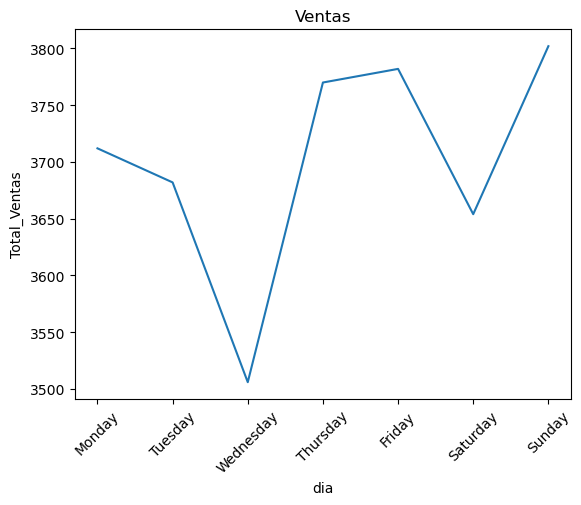

In [81]:
plt.title('Ventas')
sns.lineplot(
    data = ventas_facturacion_diasem,
    x = 'dia',
    y = 'Total_Ventas'
)
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Wednesday'),
  Text(3, 0, 'Thursday'),
  Text(4, 0, 'Friday'),
  Text(5, 0, 'Saturday'),
  Text(6, 0, 'Sunday')])

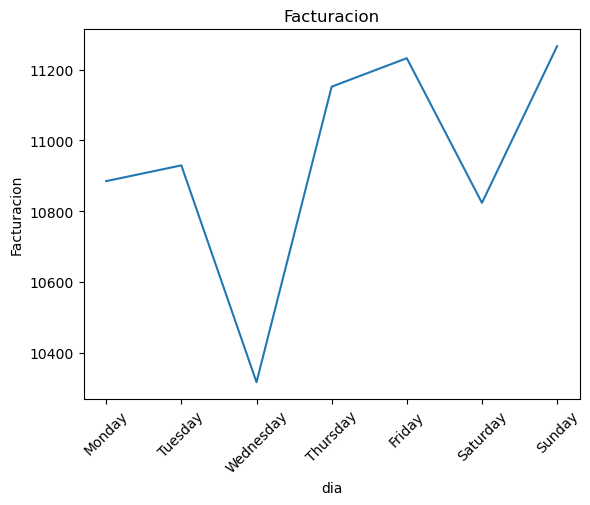

In [38]:
plt.title('Facturacion')
sns.lineplot(
    data = ventas_facturacion_diasem,
    x = 'dia',
    y = 'Facturacion'
)
plt.xticks(rotation=45)

In [78]:
precioporproducto.to_csv('precioporproducto.csv', index = False)

In [ ]:
tabla2.to_csv('ventascafeteria.csv', index = False)